In [ ]:
## KC Fitting Reliability Analysis

#Prywes et al. filter out mutants with Km CoV > 1 as unreliable (35% of the dataset).
#This analysis shows why: 99.6% of dead mutants (fitness < 0.1) have unreliable KC fits.

#Dead mutants show no growth at any [CO2] concentration — there is insufficient signal for Michaelis-Menten fitting. This visualizes a limitation the authors mention in the Methods section but do not explicitly show.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(r"C:\Users\ilija\rubiscodms\41586_2024_8455_MOESM4_ESM.csv")

# pogledaj Km_qbcov kolonu
print(df[['mutant', 'Fitness', 'Km_median', 'Km_qbcov']].head(10))
print(f"\nMutanti sa Km_qbcov < 1 (pouzdani): {len(df[df['Km_qbcov'] < 1])}")
print(f"Mutanti sa Km_qbcov > 1 (nepouzdani): {len(df[df['Km_qbcov'] > 1])}")

  mutant   Fitness  Km_median  Km_qbcov
0    Q3Y  0.397403   1.670726  1.310559
1    Q3C  0.764382   0.201704  0.215790
2    Q3D  0.451716   0.496659  0.755884
3    Q3E  0.418180   0.589618  1.060377
4    Q3F  0.698228   0.281099  0.375787
5    Q3G  0.094564   0.665454  1.582956
6    Q3H  0.887042   0.180379  0.142852
7    Q3I  0.800539   0.200042  0.249536
8    Q3K  0.814152   0.194079  0.251851
9    Q3A  0.649886   0.254431  0.408026

Mutanti sa Km_qbcov < 1 (pouzdani): 5667
Mutanti sa Km_qbcov > 1 (nepouzdani): 3093


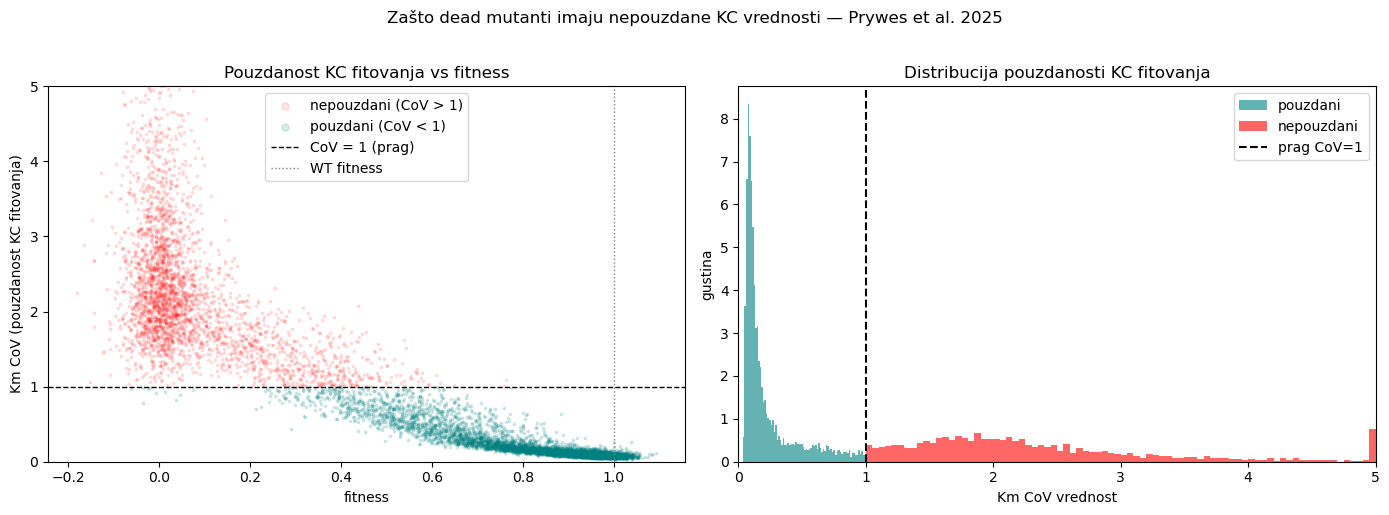


Ključni nalaz:
Mutanti sa fitness < 0.1: 2305
Od toga nepouzdani KC: 2295
Procenat: 99.6%


In [2]:
# razdvoji pouzdane i nepouzdane
pouzdani = df[df['Km_qbcov'] < 1]
nepouzdani = df[df['Km_qbcov'] >= 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafik 1: Km_qbcov vs Fitness ---
ax1 = axes[0]

ax1.scatter(nepouzdani['Fitness'], nepouzdani['Km_qbcov'],
            alpha=0.1, s=3, color='red', label='nepouzdani (CoV > 1)')
ax1.scatter(pouzdani['Fitness'], pouzdani['Km_qbcov'],
            alpha=0.15, s=3, color='teal', label='pouzdani (CoV < 1)')

ax1.axhline(y=1, color='black', linestyle='--', linewidth=1, label='CoV = 1 (prag)')
ax1.axvline(x=1.0, color='gray', linestyle=':', linewidth=1, label='WT fitness')

ax1.set_xlabel("fitness")
ax1.set_ylabel("Km CoV (pouzdanost KC fitovanja)")
ax1.set_title("Pouzdanost KC fitovanja vs fitness")
ax1.set_ylim(0, 5)
ax1.legend(markerscale=3)

# --- Grafik 2: distribucija Km_qbcov ---
ax2 = axes[1]

ax2.hist(pouzdani['Km_qbcov'], bins=80, color='teal', 
         alpha=0.6, label='pouzdani', density=True)
ax2.hist(nepouzdani['Km_qbcov'].clip(0, 5), bins=80, color='red',
         alpha=0.6, label='nepouzdani', density=True)

ax2.axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='prag CoV=1')
ax2.set_xlabel("Km CoV vrednost")
ax2.set_ylabel("gustina")
ax2.set_title("Distribucija pouzdanosti KC fitovanja")
ax2.set_xlim(0, 5)
ax2.legend()

plt.suptitle("Zašto dead mutanti imaju nepouzdane KC vrednosti — Prywes et al. 2025",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("reliability_analysis.png", dpi=200)
plt.show()

print(f"\nKljučni nalaz:")
print(f"Mutanti sa fitness < 0.1: {len(df[df['Fitness'] < 0.1])}")
print(f"Od toga nepouzdani KC: {len(df[(df['Fitness'] < 0.1) & (df['Km_qbcov'] > 1)])}")
print(f"Procenat: {len(df[(df['Fitness'] < 0.1) & (df['Km_qbcov'] > 1)]) / len(df[df['Fitness'] < 0.1]) * 100:.1f}%")